<a href="https://colab.research.google.com/github/Varshini-Anand/Nunnariacademy_Datasciencewithaibootcamp/blob/main/Nunnari_Academy_DSwith_AI_bootcamp_Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data visualisation and Heatmaps**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "/content/sample_data/automobile_data.csv"
df = pd.read_csv(url)

In [ ]:
if 'age' in df.columns:
    df['age'] = df['age'].fillna(df['age'].mean())
if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print("Missing values check:\n", df.isnull().sum().sum())

Missing values check:
 0


In [ ]:
cols_to_drop = ['Cabin', 'Ticket', 'PassengerId']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

In [ ]:
rename_dict = {
    'Pclass': 'Passenger_Class',
    'SibSp': 'Siblings_Spouses',
    'Parch': 'Parents_Children'
}
df.rename(columns=rename_dict, inplace=True)
print("\nColumns after rename:", df.columns.tolist())


Columns after rename: ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']


In [ ]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df.dropna(subset=['price', 'horsepower'], inplace=True)

In [ ]:
print("\nMost common brand:", df['make'].value_counts().idxmax())
print("Most common body-style:", df['body-style'].value_counts().idxmax())
fwd_pct = df['drive-wheels'].value_counts(normalize=True).get('fwd', 0) * 100
print(f"Percentage of fwd: {fwd_pct:.2f}%")


Most common brand: toyota
Most common body-style: sedan
Percentage of fwd: 58.29%


In [ ]:
avg_price_make = df.groupby('make')['price'].mean()
print("Most expensive brand:", avg_price_make.idxmax())

Most expensive brand: jaguar


In [ ]:
style_stats = df.groupby('body-style')['price'].agg(['min', 'max', 'mean'])
print("\nBody-style Price Stats:\n", style_stats)


Body-style Price Stats:
                  min      max          mean
body-style                                 
convertible  11595.0  37028.0  21890.500000
hardtop       8249.0  45400.0  22208.500000
hatchback     5118.0  22018.0   9958.373134
sedan         5499.0  41315.0  14459.755319
wagon         6918.0  28248.0  12500.166667


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
top_3_price = corr_matrix['price'].sort_values(ascending=False).iloc[1:4]
print("\nTop 3 columns correlated with price:\n", top_3_price)


Top 3 columns correlated with price:
 engine-size    0.873887
curb-weight    0.835090
horsepower     0.810533
Name: price, dtype: float64


In [ ]:
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0, 0.5, 'Price')

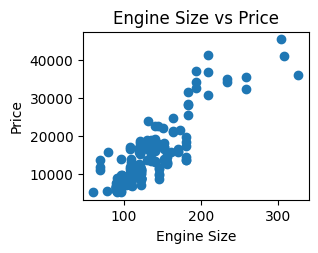

In [ ]:
plt.subplot(2, 2, 1)
plt.scatter(df['engine-size'], df['price'])
plt.title('Engine Size vs Price')
plt.xlabel('Engine Size')
plt.ylabel('Price')

Text(0.5, 1.0, 'Horsepower vs Price (by Body Style)')

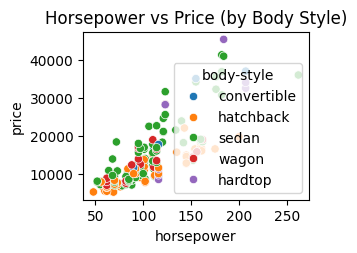

In [ ]:
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='horsepower', y='price', hue='body-style')
plt.title('Horsepower vs Price (by Body Style)')

Text(0.5, 1.0, 'Distribution of Price')

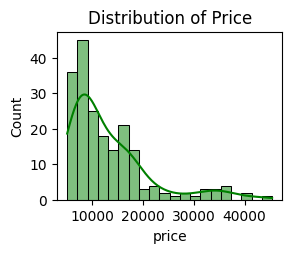

In [ ]:
plt.subplot(2, 2, 3)
sns.histplot(df['price'], bins=20, kde=True, color='green')
plt.title('Distribution of Price')

Text(0.5, 1.0, 'Correlation Heatmap')

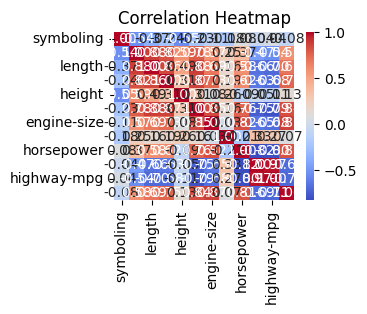

In [ ]:
plt.subplot(2, 2, 4)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

In [ ]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

**House price prediction**

Initial Missing Values:
 id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

House Condition Counts:
 condition
3    14031
4     5679
5     1701
2      172
1       30
Name: count, dtype: int64

Avg Price by Bedrooms:
 bedrooms
8     1.105077e+06
7     9.511847e+05
9     8.939998e+05
6     8.255206e+05
10    8.193333e+05
Name: price, dtype: float64

Top 3 columns correlated with price:
 sqft_living    0.702035
grade          0.667434
sqft_above     0.605567
Name: price, dtype: float64


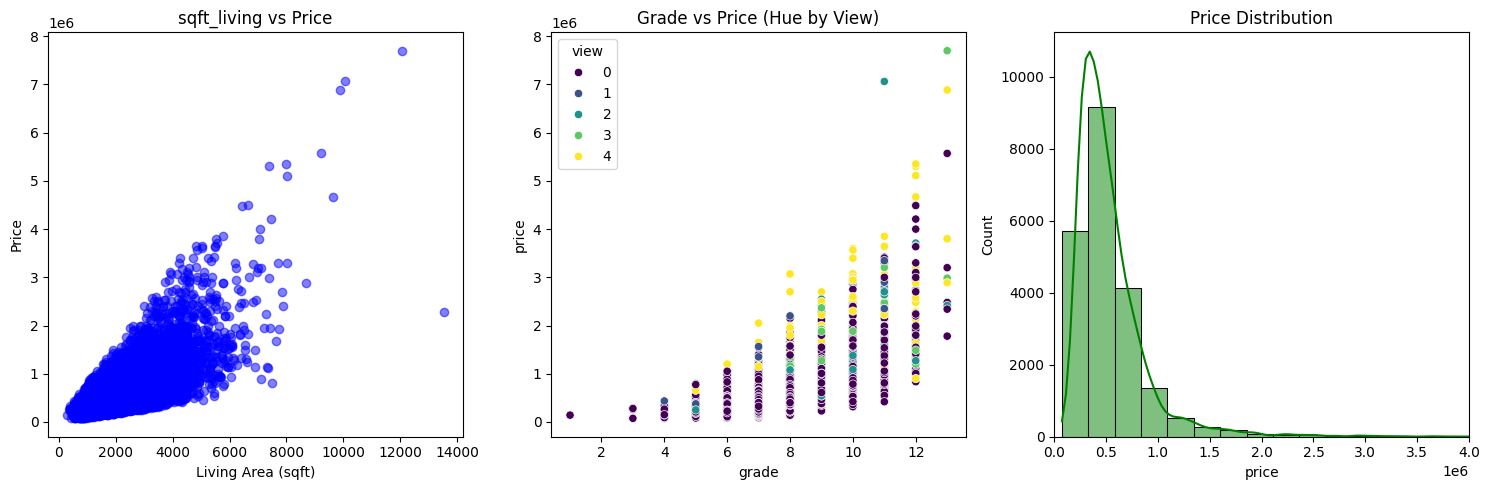

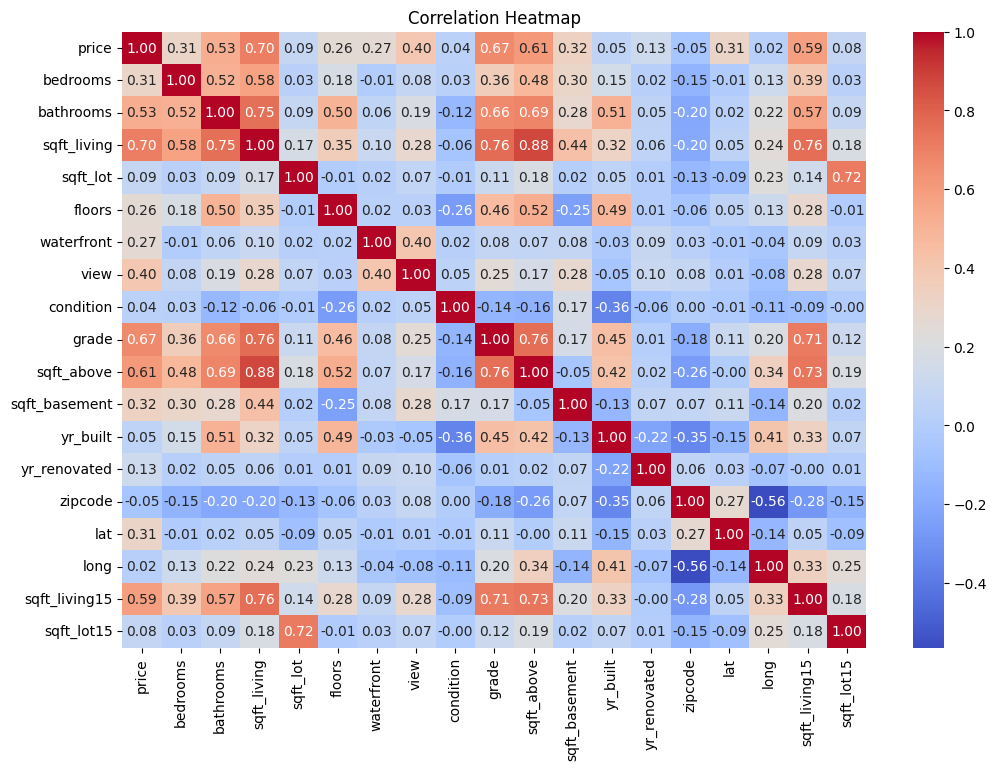

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. LOAD THE DATASET ---
url = "/content/sample_data/houseprice.csv"
df = pd.read_csv(url)

# --- 2. DATA CLEANING (Titanic Tasks Applied to House Data Logic) ---

# Task 1: Check for nulls and verify
print("Initial Missing Values:\n", df.isnull().sum())

# Task 2: drop() - Dropping 'id' and 'date' as they aren't useful for price prediction
df.drop(['id', 'date'], axis=1, inplace=True, errors='ignore')

# Task 4: astype() - Converting price to int for cleaner analysis
df['price'] = df['price'].astype(int)
df['bedrooms'] = df['bedrooms'].astype(int)

# --- 3. EXPLORATORY DATA ANALYSIS (EDA) ---

# Task 1: value_counts()
# Finding how many houses exist for each 'view' or 'condition'
print("\nHouse Condition Counts:\n", df['condition'].value_counts())

# Task 2: groupby()
# Average price by number of bedrooms
avg_price_bed = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)
print("\nAvg Price by Bedrooms:\n", avg_price_bed.head())

# Task 3: correlation()
# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Finding correlation with price
price_corr = corr_matrix['price'].sort_values(ascending=False)
print("\nTop 3 columns correlated with price:\n", price_corr[1:4])

# --- 4. DATA VISUALIZATION ---

# Task 1: Scatter Plots
plt.figure(figsize=(15, 5))

# Plot 1: sqft_living vs Price (Matplotlib)
plt.subplot(1, 3, 1)
plt.scatter(df['sqft_living'], df['price'], alpha=0.5, color='blue')
plt.title('sqft_living vs Price')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price')
# Observation: Positive correlation

# Plot 2: Grade vs Price (Seaborn)
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='grade', y='price', hue='view', palette='viridis')
plt.title('Grade vs Price (Hue by View)')

# Task 2: Histogram (Price)
plt.subplot(1, 3, 3)
sns.histplot(df['price'], bins=30, kde=True, color='green')
plt.title('Price Distribution')
plt.xlim(0, 4000000) # Limiting x-axis to see the peak better
# Observation: Right Skewed

plt.tight_layout()
plt.show()

# Task 3: Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
